In [1]:
from google.colab import files
uploaded = files.upload()

Saving SuperStoreOrders.csv to SuperStoreOrders.csv


In [2]:
import pandas as pd
import numpy as np
import sqlite3

df = pd.read_csv(
    'SuperStoreOrders.csv',
    encoding='utf-8-sig'
)

df.columns = (
    df.columns
    .str.replace('\ufeff', '', regex=False)
    .str.replace('ï»¿', '', regex=False)
    .str.strip()
)

numeric_columns = [
    'sales',
    'quantity',
    'discount',
    'profit',
    'shipping_cost',
    'year'
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column]
        .astype(str)
        .str.replace(',', '', regex=False),
        errors='raise'
    )

df['order_date'] = pd.to_datetime(
    df['order_date'],
    dayfirst=True,
    format='mixed',
    errors='raise'
)

df['ship_date'] = pd.to_datetime(
    df['ship_date'],
    dayfirst=True,
    format='mixed',
    errors='raise'
)


df = (
    df
    .sort_values('order_date')
    .reset_index(drop=True)
)

print('Размер датасета:', df.shape)

print('\nТипы основных колонок:')
print(
    df[
        [
            'order_date',
            'ship_date',
            'sales',
            'quantity',
            'discount',
            'profit'
        ]
    ].dtypes
)

print('\nПропущенные значения:')
print(
    df[
        [
            'order_date',
            'ship_date',
            'sales',
            'quantity',
            'discount',
            'profit'
        ]
    ].isna().sum()
)

print('\nОбщая сумма продаж:')
print(f"{df['sales'].sum():,.2f}")

df.head()

Размер датасета: (51290, 21)

Типы основных колонок:
order_date    datetime64[ns]
ship_date     datetime64[ns]
sales                  int64
quantity               int64
discount             float64
profit               float64
dtype: object

Пропущенные значения:
order_date    0
ship_date     0
sales         0
quantity      0
discount      0
profit        0
dtype: int64

Общая сумма продаж:
12,642,905.00


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [3]:

conn = sqlite3.connect(':memory:')

df.to_sql(
    'sales',
    conn,
    index=False,
    if_exists='replace'
)

print(
    'Строк загружено в SQLite:',
    pd.read_sql(
        'SELECT COUNT(*) AS rows_count FROM sales',
        conn
    ).iloc[0, 0]
)

Строк загружено в SQLite: 51290


In [4]:
pd.read_sql("""
SELECT category, SUM(sales) AS total_sales
FROM sales
GROUP BY category
ORDER BY total_sales DESC
""", conn)

,category,total_sales
0,Technology,4744691
1,Furniture,4110884
2,Office Supplies,3787330


In [5]:
pd.read_sql("""
SELECT market, SUM(sales) AS total_sales
FROM sales
GROUP BY market
ORDER BY total_sales DESC
""", conn)

,market,total_sales
0,APAC,3585833
1,EU,2938139
2,US,2297354
3,LATAM,2164687
4,EMEA,806184
5,Africa,783776
6,Canada,66932


In [6]:
pd.read_sql("""
SELECT region, SUM(sales) AS total_sales
FROM sales
GROUP BY region
ORDER BY total_sales DESC
""", conn)

,region,total_sales
0,Central,2822399
1,South,1600960
2,North,1248192
3,Oceania,1100207
4,Southeast Asia,884438
5,North Asia,848349
6,EMEA,806184
7,Africa,783776
8,Central Asia,752839
9,West,725514


In [7]:
pd.read_sql("""
SELECT strftime('%Y-%m', order_date) AS month, SUM(sales) AS total_sales
FROM sales
GROUP BY month
ORDER BY month
""", conn)

,month,total_sales
0,2011-01,98902
1,2011-02,91152
2,2011-03,145726
3,2011-04,116927
4,2011-05,146762
5,2011-06,215214
6,2011-07,115518
7,2011-08,207570
8,2011-09,290230
9,2011-10,199070


In [8]:
pd.read_sql("""
SELECT product_name, SUM(sales) AS total_sales
FROM sales
GROUP BY product_name
ORDER BY total_sales DESC
LIMIT 10
""", conn)

,product_name,total_sales
0,"Apple Smart Phone, Full Size",86936
1,"Cisco Smart Phone, Full Size",76441
2,"Motorola Smart Phone, Full Size",73159
3,"Nokia Smart Phone, Full Size",71904
4,Canon imageCLASS 2200 Advanced Copier,61600
5,"Hon Executive Leather Armchair, Adjustable",58200
6,"Office Star Executive Leather Armchair, Adjust...",50667
7,"Harbour Creations Executive Leather Armchair, ...",50120
8,"Samsung Smart Phone, Cordless",48654
9,"Nokia Smart Phone, with Caller ID",47880


In [9]:
pd.read_sql("""
SELECT category,
       SUM(sales) AS category_sales,
       ROUND(100.0 * SUM(sales) / (SELECT SUM(sales) FROM sales), 2) AS share_pct
FROM sales
GROUP BY category
ORDER BY category_sales DESC
""", conn)

,category,category_sales,share_pct
0,Technology,4744691,37.53
1,Furniture,4110884,32.52
2,Office Supplies,3787330,29.96


In [10]:
pd.read_sql("""
SELECT category,
       SUM(sales)  AS total_sales,
       SUM(profit) AS total_profit,
       ROUND(100.0 * SUM(profit) / SUM(sales), 1) AS margin_pct
FROM sales
GROUP BY category
ORDER BY total_profit DESC
""", conn)

,category,total_sales,total_profit,margin_pct
0,Technology,4744691,663778.73318,14.0
1,Office Supplies,3787330,518473.83430,13.7
2,Furniture,4110884,286782.25380,7.0


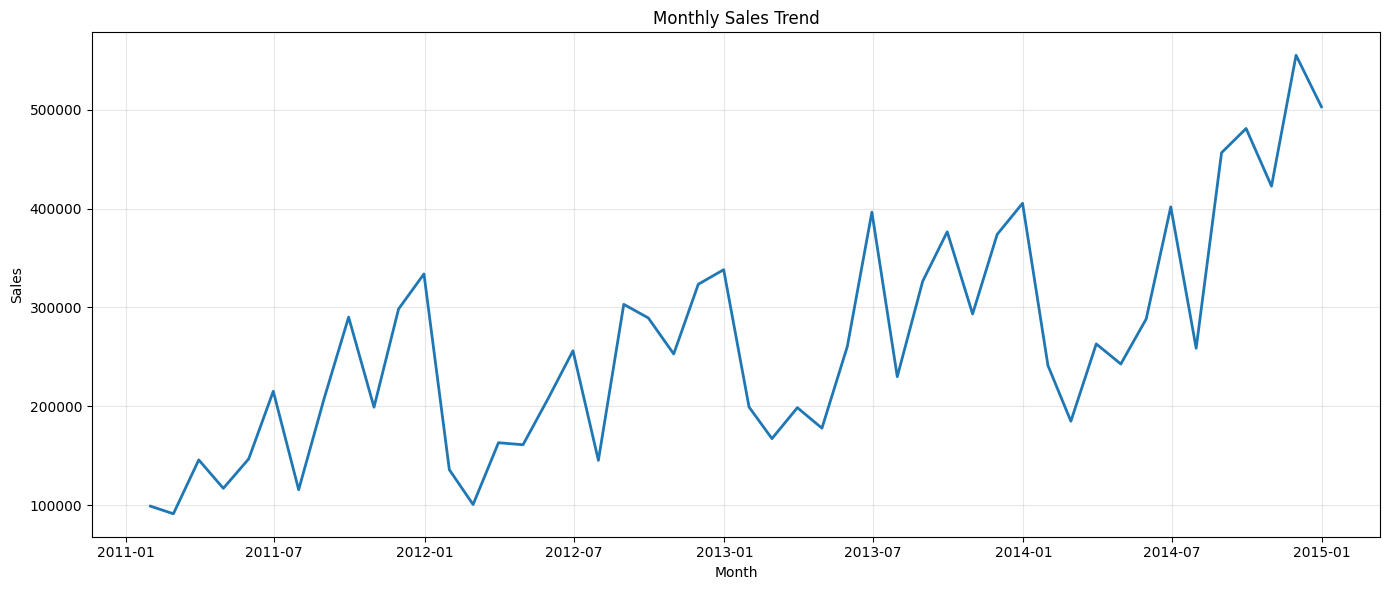

,monthly_sales
order_date,
2011-01-31 00:00:00,"98,902.00"
2011-02-28 00:00:00,"91,152.00"
2011-03-31 00:00:00,"145,726.00"
2011-04-30 00:00:00,"116,927.00"
2011-05-31 00:00:00,"146,762.00"
2011-06-30 00:00:00,"215,214.00"
2011-07-31 00:00:00,"115,518.00"
2011-08-31 00:00:00,"207,570.00"
2011-09-30 00:00:00,"290,230.00"


In [11]:
import matplotlib.pyplot as plt

monthly = (
    df
    .set_index('order_date')['sales']
    .resample('ME')
    .sum()
)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly.index,
    monthly.values,
    linewidth=2
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(
    monthly
    .rename('monthly_sales')
    .to_frame()
    .style.format({
        'monthly_sales': '{:,.2f}'
    })
)

,mom_growth_pct
order_date,
2011-01-31 00:00:00,nan%
2011-02-28 00:00:00,-7.84%
2011-03-31 00:00:00,59.87%
2011-04-30 00:00:00,-19.76%
2011-05-31 00:00:00,25.52%
2011-06-30 00:00:00,46.64%
2011-07-31 00:00:00,-46.32%
2011-08-31 00:00:00,79.69%
2011-09-30 00:00:00,39.82%


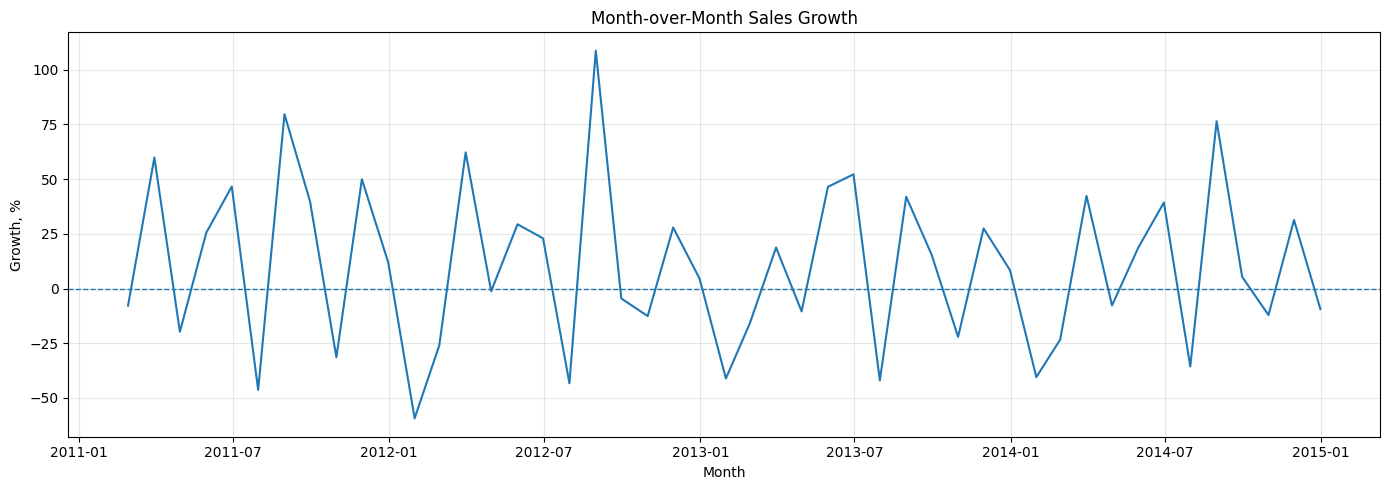

In [12]:
mom_growth = (
    monthly
    .pct_change()
    .mul(100)
    .rename('mom_growth_pct')
)

display(
    mom_growth
    .to_frame()
    .style.format({
        'mom_growth_pct': '{:.2f}%'
    })
)

plt.figure(figsize=(14, 5))

plt.plot(
    mom_growth.index,
    mom_growth.values,
    linewidth=1.5
)

plt.axhline(
    0,
    linestyle='--',
    linewidth=1
)

plt.title('Month-over-Month Sales Growth')
plt.xlabel('Month')
plt.ylabel('Growth, %')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

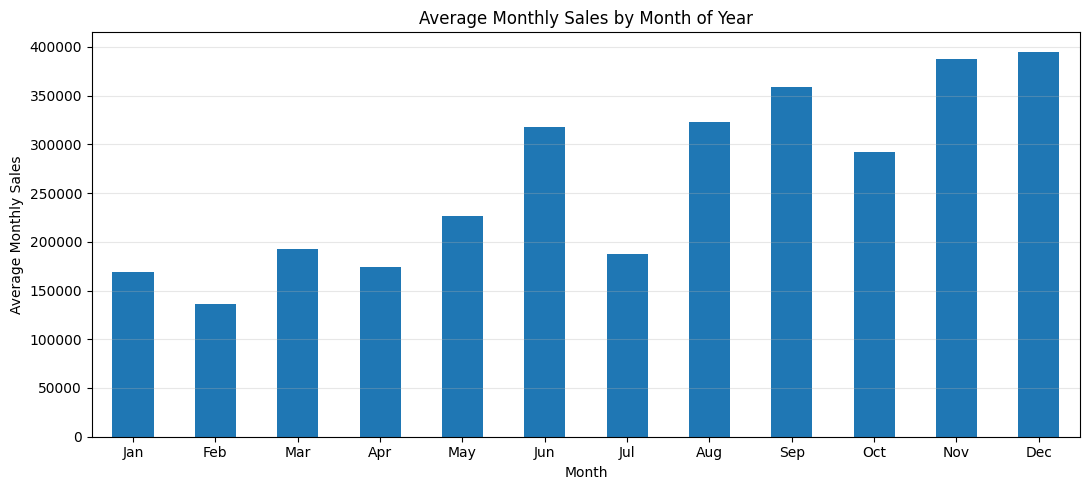

,average_monthly_sales
month_num,
Jan,"168,785.25"
Feb,"135,942.00"
Mar,"192,629.75"
Apr,"174,650.75"
May,"226,015.25"
Jun,"317,437.75"
Jul,"187,355.75"
Aug,"323,463.00"
Sep,"359,358.00"


In [13]:
monthly_sales_df = (
    monthly
    .rename('monthly_sales')
    .reset_index()
)

monthly_sales_df['month_num'] = (
    monthly_sales_df['order_date'].dt.month
)

seasonality = (
    monthly_sales_df
    .groupby('month_num')['monthly_sales']
    .mean()
)

month_names = {
    1: 'Jan',
    2: 'Feb',
    3: 'Mar',
    4: 'Apr',
    5: 'May',
    6: 'Jun',
    7: 'Jul',
    8: 'Aug',
    9: 'Sep',
    10: 'Oct',
    11: 'Nov',
    12: 'Dec'
}

seasonality.index = (
    seasonality.index.map(month_names)
)

plt.figure(figsize=(11, 5))

seasonality.plot(
    kind='bar'
)

plt.title('Average Monthly Sales by Month of Year')
plt.xlabel('Month')
plt.ylabel('Average Monthly Sales')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

display(
    seasonality
    .rename('average_monthly_sales')
    .to_frame()
    .style.format({
        'average_monthly_sales': '{:,.2f}'
    })
)

In [14]:
Q1 = df['sales'].quantile(0.25)
Q3 = df['sales'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['sales'] < lower_bound)
    |
    (df['sales'] > upper_bound)
].copy()

print(f'Q1: {Q1:,.2f}')
print(f'Q3: {Q3:,.2f}')
print(f'IQR: {IQR:,.2f}')
print(f'Lower bound: {lower_bound:,.2f}')
print(f'Upper bound: {upper_bound:,.2f}')
print(f'Number of potential outliers: {len(outliers):,}')
print(f'Share of dataset: {len(outliers) / len(df):.2%}')

display(
    outliers[
        [
            'order_id',
            'order_date',
            'product_name',
            'category',
            'sales',
            'quantity',
            'profit'
        ]
    ]
    .sort_values('sales', ascending=False)
    .head(10)
)

Q1: 31.00
Q3: 251.00
IQR: 220.00
Lower bound: -299.00
Upper bound: 581.00
Number of potential outliers: 5,655
Share of dataset: 11.03%


,order_id,order_date,product_name,category,sales,quantity,profit
1111,CA-2011-145317,2011-03-18,Cisco TelePresence System EX90 Videoconferenci...,Technology,22638,6,-1811.0784
29553,CA-2013-118689,2013-10-03,Canon imageCLASS 2200 Advanced Copier,Technology,17500,5,8399.9760
36258,CA-2014-140151,2014-03-24,Canon imageCLASS 2200 Advanced Copier,Technology,14000,4,6719.9808
46553,CA-2014-127180,2014-10-23,Canon imageCLASS 2200 Advanced Copier,Technology,11200,4,3919.9888
48189,CA-2014-166709,2014-11-18,Canon imageCLASS 2200 Advanced Copier,Technology,10500,3,5039.9856
33065,CA-2013-117121,2013-12-18,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,9893,13,4946.3700
5548,CA-2011-116904,2011-09-23,Ibico EPK-21 Electric Binding System,Office Supplies,9450,5,4630.4755
22500,US-2013-107440,2013-04-17,"3D Systems Cube Printer, 2nd Generation, Magenta",Technology,9100,7,2365.9818
20705,CA-2013-158841,2013-02-02,HP Designjet T520 Inkjet Large Format Printer ...,Technology,8750,5,2799.9840
23608,CA-2013-143714,2013-05-24,Canon imageCLASS 2200 Advanced Copier,Technology,8400,4,1119.9968


,sales,quantity,discount,profit
sales,1.000,0.314,-0.087,0.486
quantity,0.314,1.000,-0.020,0.105
discount,-0.087,-0.020,1.000,-0.316
profit,0.486,0.105,-0.316,1.000


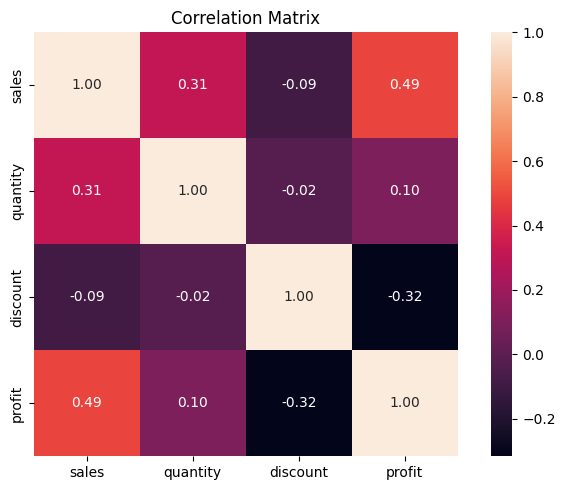

In [15]:
import seaborn as sns

correlation_matrix = df[
    [
        'sales',
        'quantity',
        'discount',
        'profit'
    ]
].corr()

display(
    correlation_matrix.style.format('{:.3f}')
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    square=True
)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

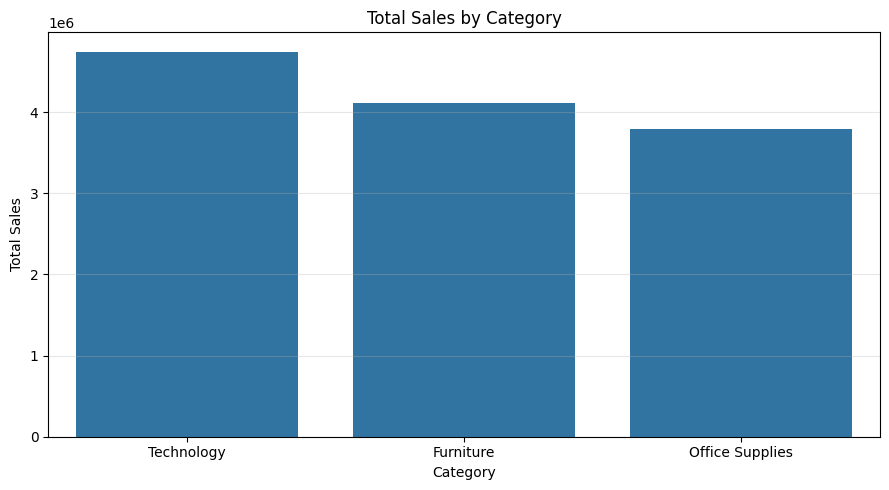

,category,total_sales
2,Technology,"4,744,691.00"
0,Furniture,"4,110,884.00"
1,Office Supplies,"3,787,330.00"


In [16]:
category_sales = (
    df
    .groupby(
        'category',
        as_index=False
    )
    .agg(
        total_sales=('sales', 'sum')
    )
    .sort_values(
        'total_sales',
        ascending=False
    )
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=category_sales,
    x='category',
    y='total_sales',
    errorbar=None
)

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

display(
    category_sales.style.format({
        'total_sales': '{:,.2f}'
    })
)

In [17]:

sales_clean = df.copy()

sales_clean.to_csv(
    'sales_clean.csv',
    index=False,
    encoding='utf-8-sig'
)

sales_clean.to_excel(
    'sales_clean.xlsx',
    index=False,
    engine='openpyxl'
)

print('Размер экспортируемого файла:', sales_clean.shape)

print('\nПропуски в основных колонках:')
print(
    sales_clean[
        [
            'order_date',
            'ship_date',
            'sales',
            'quantity',
            'profit'
        ]
    ].isna().sum()
)

from google.colab import files

files.download('sales_clean.csv')
files.download('sales_clean.xlsx')

Размер экспортируемого файла: (51290, 21)

Пропуски в основных колонках:
order_date    0
ship_date     0
sales         0
quantity      0
profit        0
dtype: int64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>